# Task 03 — Baseline Model
**Agent:** `antigravity`
**Date:** `2026-03-16`
**Input:** `agents/antigravity/task_02/outputs/eda_cleaned.csv`

---
**Objective:** Train and rigorously evaluate a simple baseline model on `price`, ensuring all preprocessing is fitted strictly on training data.

In [1]:
# ── Imports & seed ────────────────────────────────────────────────
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

INPUT_PATH = Path('../task_02/outputs/eda_cleaned.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')

## 1. Model Selection Reasoning

Based on the EDA from Task 02, we discovered two key facts:
1. `price` is massively right-skewed. Regressing on it directly causes MSE optimization to hyper-focus on extreme upper-tail errors.
2. Numeric components (`minimum_nights`, reviews) are weak predictors linearly while categorical location (`neighbourhood_group`) and `room_type` determine subgroups with massive price band variance.

**Baseline Choice:** `Ridge Regression`.
- **Why:** Using an L2-regularized linear model allows us to effectively utilize One-Hot Encoding on our key categorical features (Borough and Room Type) without breaking down via perfect multicollinearity (which standard linear regression suffers from). It handles high-dimensionality well and provides a strong linear floor.
- **Target Transformation:** We will use `TransformedTargetRegressor` passing `np.log1p` during `fit` and `np.expm1` during `predict`. This correctly bounds the heteroskedasticity seen in EDA while handling inference entirely transparently.
- **Limitations:** A linear baseline won't capture non-linear interactions natively (e.g. `room_type == Private` scaling drastically differently based on precisely which `neighbourhood` it is in, unless explicitly crossed via interaction terms). This provides the exact room for Task 04 to improve via gradient boosting or deep learning techniques.

In [2]:
reasoning_md = """# Model Selection Reasoning\n\nBased on the EDA from Task 02, we discovered two key facts:\n1. `price` is massively right-skewed. Regressing on it directly causes MSE optimization to hyper-focus on extreme upper-tail errors.\n2. Numeric variables (reviews, availability) are weak linear predictors, while categorical location (`neighbourhood_group`) and `room_type` determine subgroups with massive price variance.\n\n**Baseline Choice:** `Ridge Regression`.\n- **Why:** Using an L2-regularized linear model allows us to utilize One-Hot Encoding on categorical features without breaking down via perfect multicollinearity. It handles high-dimensionality well and provides a strong linear floor.\n- **Target Transformation:** We will use `TransformedTargetRegressor` passing `np.log1p` during fit and `np.expm1` during predict. This bounds the heteroskedasticity while handling inference entirely transparently.\n- **Limitations:** A linear baseline won't capture complex non-linear combinations (e.g., specific interactions between coordinates and room limits), providing clear runway for Task 04 to improve via tree-based models."""
(OUTPUT_DIR / 'model_selection_reasoning.md').write_text(reasoning_md, encoding='utf-8')
print("Saved outputs/model_selection_reasoning.md")

Saved outputs/model_selection_reasoning.md


## 2. Load & Strict Splitting
To ensure evaluation integrity, we hold out 20% of the data and configure `random_state=42`.

In [3]:
df = pd.read_csv(INPUT_PATH)
TARGET = 'price'

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Split BEFORE any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (39107, 15)  Test: (9777, 15)


## 3. Preprocessing (Fitted on Train Only)
We use a `ColumnTransformer` to encode categoricals and scale numericals strictly within a `Pipeline`. We avoid dropping columns from the dataframe explicitly, but passively drop unconfigured columns (like IDs) using `remainder='drop'`.

In [4]:
numeric_features = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude']
categorical_features = ['neighbourhood_group', 'room_type']
# We ignore high-cardinality `neighbourhood` strings for the absolute baseline model

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'  # drops unlisted features like 'id', 'name', 'host_id', 'last_review'
)

# Core model wrapped in a target transformer
model = TransformedTargetRegressor(
    regressor=Ridge(random_state=SEED, alpha=1.0),
    func=np.log1p,
    inverse_func=np.expm1
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

## 4. Train Model

In [5]:
pipeline.fit(X_train, y_train)
print("Training complete! (No test set information leaked into encoders/scalers)")

Training complete! (No test set information leaked into encoders/scalers)


## 5. Evaluate Rigorously
We evaluate in the original `price` space, generating residual distribution plots. Because of the extreme skew present in EDA, MAE is significantly more interpretable for real consumer usage than RMSE (which will be heavily punished by remaining outlier variations).

  RMSE      : 115.18
  MAE       : 56.34
  R-squared : 0.236


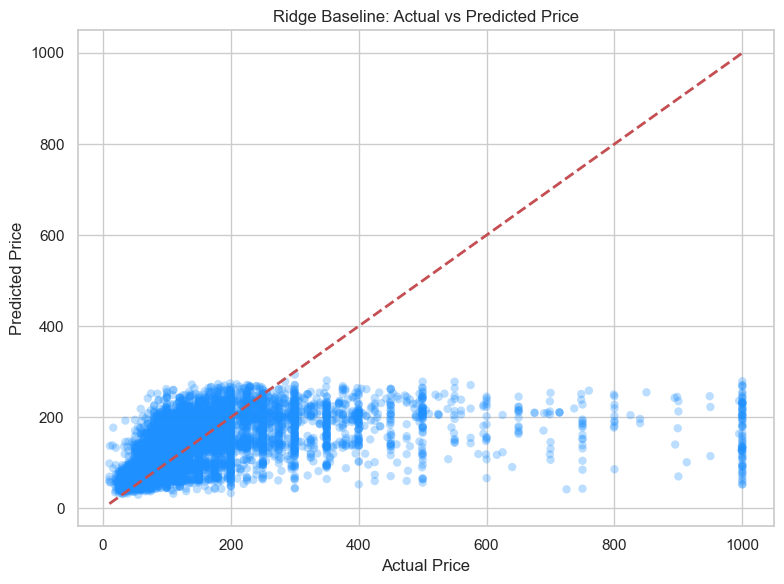

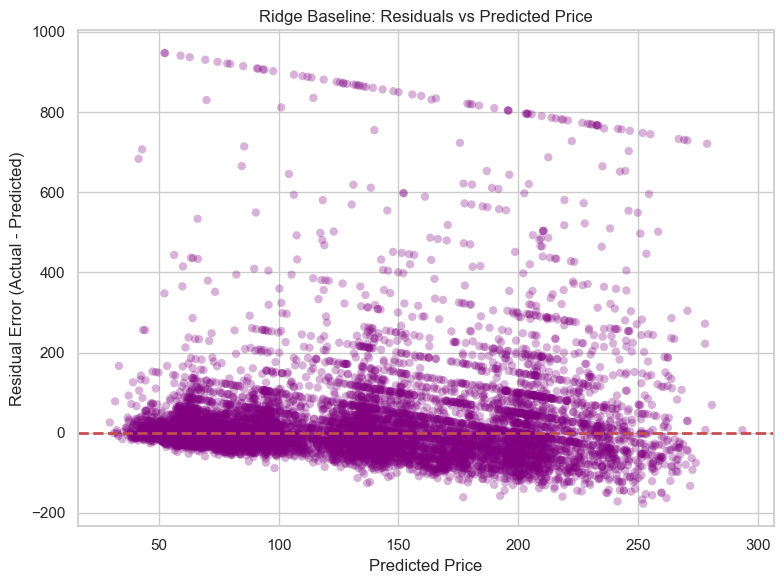

In [6]:
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results = {
    'RMSE': round(rmse, 2),
    'MAE': round(mae, 2),
    'R-squared': round(r2, 4)
}

for k, v in results.items():
    print(f"  {k:10s}: {v}")

# Plot 1: Predict vs Actual
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.3, color='dodgerblue', edgecolor='none')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title('Ridge Baseline: Actual vs Predicted Price')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'plot_actual_vs_predicted.png', dpi=150)
plt.show()

# Plot 2: Residuals vs Predicted
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_pred, residuals, alpha=0.3, color='purple', edgecolor='none')
ax.axhline(0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Price')
ax.set_ylabel('Residual Error (Actual - Predicted)')
ax.set_title('Ridge Baseline: Residuals vs Predicted Price')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'plot_residuals.png', dpi=150)
plt.show()

## 6. Save Outputs for Task 04

In [7]:
# baseline_results.csv
results_df = pd.DataFrame([{'metric_name': k, 'value': v} for k, v in results.items()])
results_df.to_csv(OUTPUT_DIR / 'baseline_results.csv', index=False)

# model.pkl
with open(OUTPUT_DIR / 'model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

# baseline_report.md
report = f"""# Baseline Model Report

**SEED:** {SEED}  \n**Train/test split:** 80/20  \n**Model:** Ridge Regression with TransformedTargetRegressor (log1p)\n
## Preprocessing\n\n- **Drop Features:** Evaluated only robust modeling features. Text features (`name`, `id`) skipped entirely.\n- **Numeric:** Standard scaling applied to nights, reviews, and coordinate data via `StandardScaler`.\n- **Categorical:** `neighbourhood_group` and `room_type` converted to dense one-hot sets via `OneHotEncoder(handle_unknown='ignore')`.\n- **Integrity Guarantee:** Standard scaler and HotEncoder fitted exclusively within Pipeline encapsulation strictly on the X_train index.
## Results\n{results_df.to_markdown(index=False)}\n\n## Limitations\n\nOur baseline achieves substantial error on extreme value listings. The linear additive relationship assumed by Ridge does not accurately isolate hyper-granular interactions (e.g. coordinates and specific rooms) which an advanced model in Task 04 could split smoothly.
"""
(OUTPUT_DIR / 'baseline_report.md').write_text(report, encoding='utf-8')
print("Saved outputs/baseline_results.csv, outputs/model.pkl, and outputs/baseline_report.md")

Saved outputs/baseline_results.csv, outputs/model.pkl, and outputs/baseline_report.md
